# SolarMarket-Sizer
### Renewable Energy Sizing & Sensitivity Analysis for an Urban Market

This notebook walks through the full analysis:
1. Define an estimated hourly load profile for the market
2. Pull solar resource / PV generation data from PVGIS for the chosen site
3. Run a PV + battery dispatch simulation
4. Sweep across system sizes and visualize the tradeoffs
5. Summarize the recommended sizing and its assumptions/limitations

See `README.md` for the full methodology write-up and known simplifications.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.load_profile import generate_year_profile
from src.pvgis import fetch_pvgis_hourly, load_pvgis_csv, scale_pv_output
from src.battery_model import simulate_pv_battery, summarize_run, sensitivity_sweep

pd.set_option("display.max_columns", None)
%matplotlib inline


## 1. Site & market assumptions

Fill these in for your chosen market. Keep them explicit — this is the
single biggest source of uncertainty in the whole analysis, so being
transparent about assumptions matters more than false precision.


In [2]:
# --- SITE ---
SITE_NAME = "Example Market, Lagos, Nigeria"   # <-- update
LATITUDE = 6.5244                               # <-- update
LONGITUDE = 3.3792                              # <-- update

# --- MARKET LOAD ASSUMPTIONS ---
NUM_STALLS = 80
AVG_KW_PER_STALL = 0.35        # lighting, small fridges, phone charging, fans
FIXED_LOADS_KW = 5             # common-area lighting, water pumps, security
PEAK_LOAD_KW = NUM_STALLS * AVG_KW_PER_STALL + FIXED_LOADS_KW

OPEN_HOUR = 6
CLOSE_HOUR = 19
COVERED_MARKET = True          # has refrigeration / indoor lighting all day
MARKET_DAYS = [0, 1, 2, 3, 4, 5]   # closed Sundays (0=Mon ... 6=Sun)

print(f"Assumed peak load: {PEAK_LOAD_KW:.1f} kW")


Assumed peak load: 33.0 kW


## 2. Build the hourly load profile

Total annual demand (kWh): 172140.0


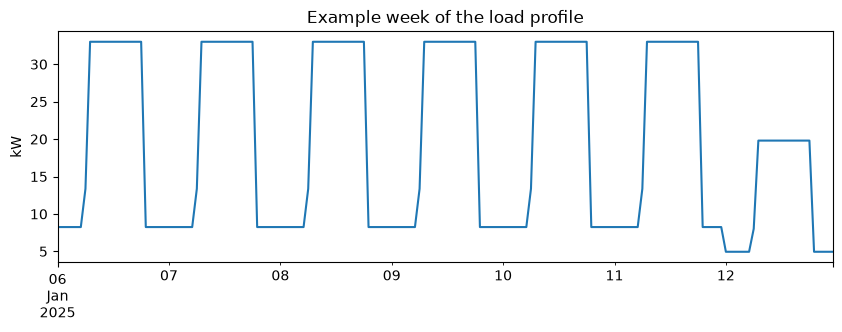

In [3]:
load_df = generate_year_profile(
    peak_load_kw=PEAK_LOAD_KW,
    open_hour=OPEN_HOUR,
    close_hour=CLOSE_HOUR,
    covered_market=COVERED_MARKET,
    market_days=MARKET_DAYS,
    periods_days=365,
)

print("Total annual demand (kWh):", round(load_df["load_kw"].sum(), 0))
load_df["load_kw"].loc["2025-01-06":"2025-01-12"].plot(
    figsize=(10, 3), title="Example week of the load profile"
)
plt.ylabel("kW")
plt.show()


## 3. Solar resource data (PVGIS)

`fetch_pvgis_hourly()` makes a live call to the PVGIS API and needs
internet access. If you're working somewhere without external network
access, download the CSV manually from
https://re.jrc.ec.europa.eu/pvg_tools/en/ for your coordinates and load it
with `load_pvgis_csv("../data/pvgis_raw.csv")` instead — both paths are
shown below.


In [6]:
# --- Option A: live API call ---
pvgis_df = fetch_pvgis_hourly(
    lat=LATITUDE,
    lon=LONGITUDE,
    peakpower_kw=1.0,   # 1 kWp reference system; we scale this later
    tilt_deg=15,        # roughly latitude-appropriate; adjust per site
    azimuth_deg=0,      # 0 = south-facing
    year_start=2019,
    year_end=2019,
)

# --- Option B: manually downloaded CSV (uncomment if no internet access) ---
# pvgis_df = load_pvgis_csv("../data/pvgis_raw.csv")

pvgis_df.head()


,poa_global_wm2,pv_power_w,temp_air_c
time,,,
2019-01-01 00:06:00,0.0,0.0,26.74
2019-01-01 01:06:00,0.0,0.0,26.56
2019-01-01 02:06:00,0.0,0.0,26.20
2019-01-01 03:06:00,0.0,0.0,25.93
2019-01-01 04:06:00,0.0,0.0,25.80


Annual yield per kWp installed (kWh/kWp): 1329.0


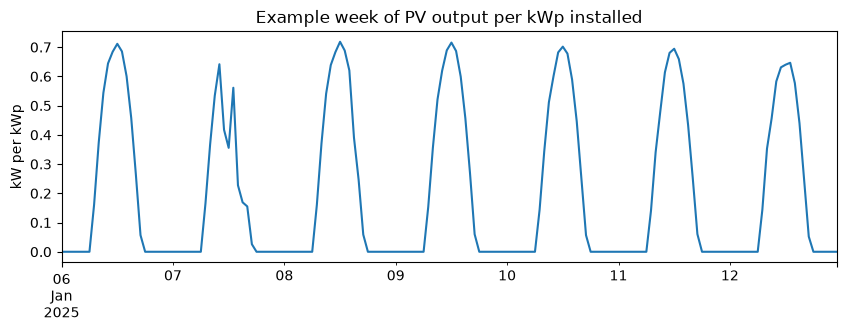

In [7]:
# Reindex PVGIS output onto the same calendar year as the load profile so
# the two series line up hour-for-hour (PVGIS years won't match load_df's
# 2025 index by default).
pv_1kwp = pvgis_df["pv_power_w"] / 1000.0   # convert W -> kW
pv_1kwp.index = load_df.index[: len(pv_1kwp)]  # align lengths/calendar

print("Annual yield per kWp installed (kWh/kWp):", round(pv_1kwp.sum(), 0))
pv_1kwp.loc["2025-01-06":"2025-01-12"].plot(
    figsize=(10, 3), title="Example week of PV output per kWp installed"
)
plt.ylabel("kW per kWp")
plt.show()


## 4. Single-scenario dispatch simulation

Pick one PV size and one battery size to sanity-check the dispatch logic
before running the full sweep.


In [8]:
TEST_PV_KWP = 25
TEST_BATTERY_KWH = 20

test_pv_series = pv_1kwp * TEST_PV_KWP

sim = simulate_pv_battery(
    load_kw=load_df["load_kw"],
    pv_gen_kw=test_pv_series,
    battery_capacity_kwh=TEST_BATTERY_KWH,
    battery_power_kw=TEST_BATTERY_KWH * 0.5,
)

kpis = summarize_run(sim)
for k, v in kpis.items():
    print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")


total_load_kwh: 172139.583
total_pv_generation_kwh: 33213.724
total_grid_import_kwh: 138916.372
total_curtailed_kwh: 0.000
renewable_fraction: 0.193
curtailment_fraction: 0.000


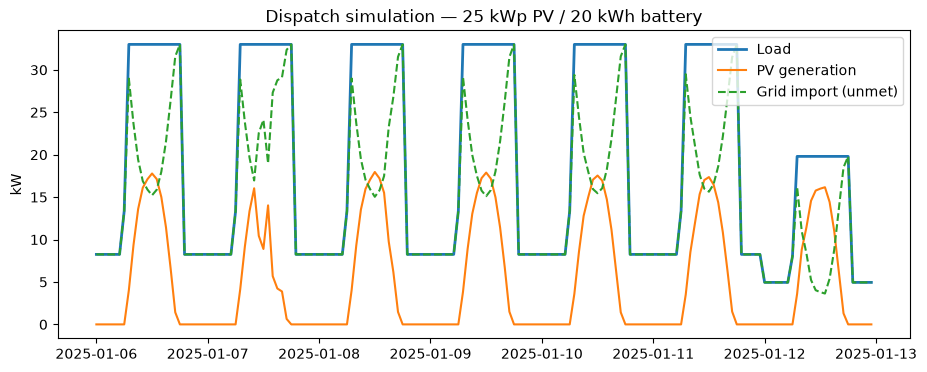

In [9]:
week = sim.loc["2025-01-06":"2025-01-12"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(week.index, week["load_kw"], label="Load", linewidth=2)
ax.plot(week.index, week["pv_gen_kw"], label="PV generation", linewidth=1.5)
ax.plot(week.index, week["grid_import_kw"], label="Grid import (unmet)", linestyle="--")
ax.set_ylabel("kW")
ax.set_title(f"Dispatch simulation — {TEST_PV_KWP} kWp PV / {TEST_BATTERY_KWH} kWh battery")
ax.legend()
plt.show()


## 5. Sensitivity sweep across PV and battery sizes

*** Update `pv_cost_per_kwp` and `battery_cost_per_kwh` below with current
benchmark figures (e.g. from IRENA or NREL cost reports) before citing the
capex numbers anywhere. The defaults are placeholders. ***


In [10]:
PV_SIZES_KWP = [10, 20, 30, 40, 50, 75, 100]
BATTERY_SIZES_KWH = [0, 10, 20, 40, 60, 100]

sweep_df = sensitivity_sweep(
    load_kw=load_df["load_kw"],
    pv_gen_per_kwp=pv_1kwp,
    pv_sizes_kwp=PV_SIZES_KWP,
    battery_sizes_kwh=BATTERY_SIZES_KWH,
    pv_cost_per_kwp=700,        # PLACEHOLDER - update with current benchmark
    battery_cost_per_kwh=300,   # PLACEHOLDER - update with current benchmark
)

sweep_df.to_csv("../outputs/sensitivity_sweep_results.csv", index=False)
sweep_df.head(10)


,pv_size_kwp,battery_size_kwh,total_load_kwh,total_pv_generation_kwh,total_grid_import_kwh,total_curtailed_kwh,renewable_fraction,curtailment_fraction,capex_estimate
0,10,0,172139.583,13285.4896,158854.093400,0.0,0.077179,0.0,7000
1,10,10,172139.583,13285.4896,158849.349984,0.0,0.077206,0.0,10000
2,10,20,172139.583,13285.4896,158844.606567,0.0,0.077234,0.0,13000
3,10,40,172139.583,13285.4896,158835.119734,0.0,0.077289,0.0,19000
4,10,60,172139.583,13285.4896,158825.632901,0.0,0.077344,0.0,25000
5,10,100,172139.583,13285.4896,158806.659235,0.0,0.077454,0.0,37000
6,20,0,172139.583,26570.9792,145568.603800,0.0,0.154357,0.0,14000
7,20,10,172139.583,26570.9792,145563.860384,0.0,0.154385,0.0,17000
8,20,20,172139.583,26570.9792,145559.116967,0.0,0.154412,0.0,20000
9,20,40,172139.583,26570.9792,145549.630134,0.0,0.154467,0.0,26000


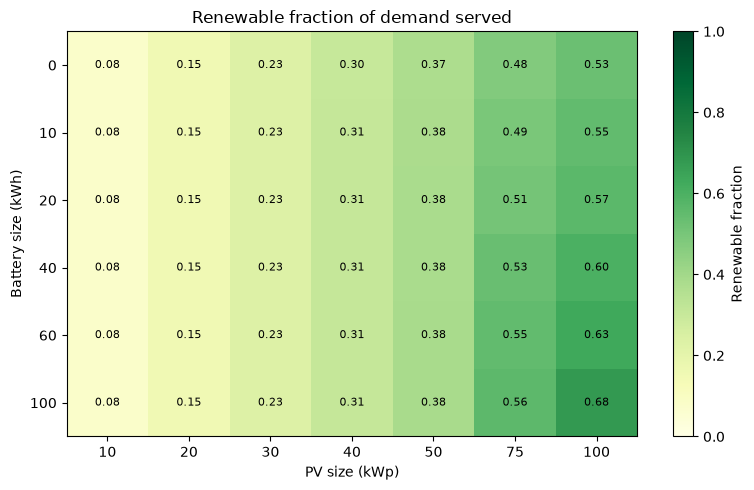

In [11]:
pivot = sweep_df.pivot(
    index="battery_size_kwh", columns="pv_size_kwp", values="renewable_fraction"
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("PV size (kWp)")
ax.set_ylabel("Battery size (kWh)")
ax.set_title("Renewable fraction of demand served")
fig.colorbar(im, label="Renewable fraction")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/renewable_fraction_heatmap.png", dpi=150)
plt.show()


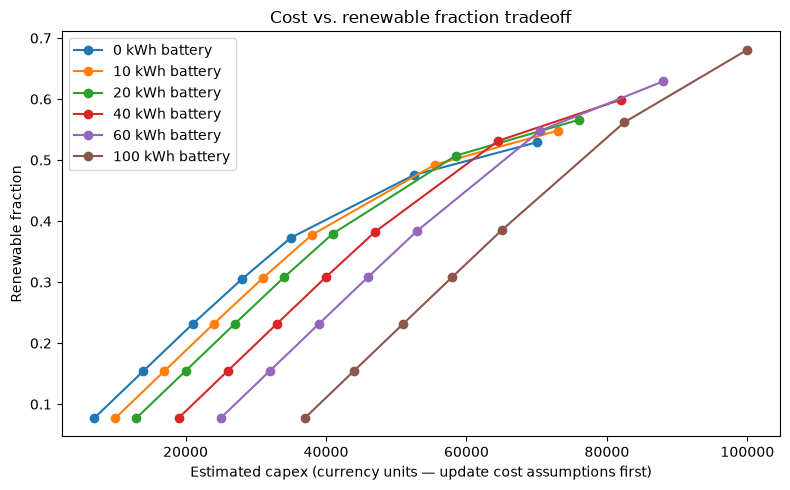

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for batt in BATTERY_SIZES_KWH:
    subset = sweep_df[sweep_df["battery_size_kwh"] == batt]
    ax.plot(subset["capex_estimate"], subset["renewable_fraction"], marker="o", label=f"{batt} kWh battery")

ax.set_xlabel("Estimated capex (currency units — update cost assumptions first)")
ax.set_ylabel("Renewable fraction")
ax.set_title("Cost vs. renewable fraction tradeoff")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/cost_vs_renewable_fraction.png", dpi=150)
plt.show()


## 6. Marginal returns: where does battery storage actually start paying off?

A first look at the heatmap above shows something worth stating explicitly:
**at small PV sizes, adding a battery barely moves the renewable fraction at
all.** That's not a modeling error — a battery can only store *surplus* PV
generation, and if the PV system rarely produces more than the market is
drawing at that moment, there's nothing for it to charge from. Storage only
starts earning its cost once PV capacity is large enough to routinely
overshoot demand.

The cell below quantifies this by computing the renewable-fraction gain
per €1,000 of estimated capex, relative to the smallest system in the
sweep. Diminishing returns should be visible as PV/battery size increases.


In [13]:
baseline = sweep_df.loc[sweep_df["capex_estimate"].idxmin()]

sweep_df["delta_renewable_fraction"] = (
    sweep_df["renewable_fraction"] - baseline["renewable_fraction"]
)
sweep_df["delta_capex"] = sweep_df["capex_estimate"] - baseline["capex_estimate"]
sweep_df["renewable_fraction_gain_per_1000"] = (
    sweep_df["delta_renewable_fraction"] / (sweep_df["delta_capex"] / 1000)
).replace([float("inf"), -float("inf")], pd.NA)

sweep_df.sort_values("renewable_fraction_gain_per_1000", ascending=False).head(10)[
    ["pv_size_kwp", "battery_size_kwh", "renewable_fraction",
     "curtailment_fraction", "capex_estimate", "renewable_fraction_gain_per_1000"]
]


,pv_size_kwp,battery_size_kwh,renewable_fraction,curtailment_fraction,capex_estimate,renewable_fraction_gain_per_1000
6,20,0,0.154357,0.000000,14000,0.011026
12,30,0,0.231326,0.000904,21000,0.011011
18,40,0,0.304637,0.013209,28000,0.010831
24,50,0,0.372781,0.033979,35000,0.010557
25,50,10,0.377497,0.020478,38000,0.009688
19,40,10,0.306591,0.006273,31000,0.009559
13,30,10,0.231542,0.000000,24000,0.009080
26,50,20,0.379619,0.014449,41000,0.008895
30,75,0,0.475402,0.178698,52500,0.008752
31,75,10,0.492387,0.146147,55500,0.008561


## 7. Pick a recommended system size and summarize

Rather than chasing a single fixed renewable-fraction target (a naive
"75% or bust" threshold may not even be reachable — check the max value in
`sweep_df["renewable_fraction"]` before assuming it is), this project
selects **two** candidate systems and lets the tradeoff itself be the
finding:

- **Cost-efficient pick**: the system with the best renewable-fraction
  gain per €1,000 spent, among options with low curtailment (< 5%) — the
  point where you're not yet paying for wasted generation.
- **Renewable-maximizing pick**: the system that reaches the highest
  renewable fraction anywhere in the sweep, accepting that this will come
  with higher curtailment and a worse cost-per-percentage-point.

Presenting both, rather than a single number, is a more defensible planning
conclusion — and a better story for a portfolio project: it shows you can
reason about a tradeoff rather than just optimizing one metric in isolation.


In [14]:
MIN_RENEWABLE_FRACTION = 0.30   # floor so the "cheapest first unit" doesn't win by default
MAX_ACCEPTABLE_CURTAILMENT = 0.05  # 5% — adjust based on your own judgement

# Without a minimum renewable-fraction floor, the gain-per-euro metric
# always favors the very first, smallest increment of PV (the first kWp
# is always the "cheapest" percentage point from a zero baseline) — which
# isn't a usable recommendation. The floor keeps the pick meaningful.
viable = sweep_df[
    (sweep_df["curtailment_fraction"] <= MAX_ACCEPTABLE_CURTAILMENT)
    & (sweep_df["renewable_fraction"] >= MIN_RENEWABLE_FRACTION)
]
cost_efficient_pick = viable.sort_values(
    "renewable_fraction_gain_per_1000", ascending=False
).iloc[0]

renewable_maximizing_pick = sweep_df.sort_values("renewable_fraction", ascending=False).iloc[0]

print("=== Cost-efficient pick (renewable fraction gain per euro, low curtailment) ===")
print(cost_efficient_pick[[
    "pv_size_kwp", "battery_size_kwh", "renewable_fraction",
    "curtailment_fraction", "capex_estimate"
]].to_string())

print()
print("=== Renewable-maximizing pick (highest achievable renewable fraction) ===")
print(renewable_maximizing_pick[[
    "pv_size_kwp", "battery_size_kwh", "renewable_fraction",
    "curtailment_fraction", "capex_estimate"
]].to_string())

print()
print(f"Max renewable fraction achievable in this sweep: "
      f"{sweep_df['renewable_fraction'].max():.1%}")
print("If this is below your target, the ceiling is set by nighttime/"
      "off-hours load that no economically-sized PV+battery combination "
      "in this sweep can fully cover — worth stating explicitly rather "
      "than silently lowering the target.")


=== Cost-efficient pick (renewable fraction gain per euro, low curtailment) ===
pv_size_kwp                40.000000
battery_size_kwh            0.000000
renewable_fraction          0.304637
curtailment_fraction        0.013209
capex_estimate          28000.000000

=== Renewable-maximizing pick (highest achievable renewable fraction) ===
pv_size_kwp                100.000000
battery_size_kwh           100.000000
renewable_fraction           0.680799
curtailment_fraction         0.096451
capex_estimate          100000.000000

Max renewable fraction achievable in this sweep: 68.1%
If this is below your target, the ceiling is set by nighttime/off-hours load that no economically-sized PV+battery combination in this sweep can fully cover — worth stating explicitly rather than silently lowering the target.


### Summary (fill in after running the cells above)

Write 4-6 sentences here stating:

- The two recommended systems (cost-efficient vs. renewable-maximizing),
  their renewable fractions, and rough capex
- Which one you'd actually propose for the market, and why (e.g. budget
  constraints favor the cost-efficient pick; a grant or resilience
  requirement might favor the renewable-maximizing pick)
- The main assumptions this depends on (load profile estimate, PVGIS
  single-year historical data, greedy dispatch logic, placeholder €/kWp
  and €/kWh costs — **update these with current benchmark figures before
  citing capex anywhere formal**)
- Why the renewable fraction plateaus well below 100% (nighttime/off-hours
  demand outlives what PV + a reasonably-sized battery can supply)
- What you'd do next with more time (siting/GIS analysis, real metering
  data, demand-response strategies, multi-year weather variability, a
  finer battery-power-to-capacity ratio sweep)
